# Download the file

In [3]:
import pandas as  pd
final_ml_df = pd.read_csv(r"F:\downloads microsodt\GSE108966_EST_RIF_ml_dataset.csv")
display(final_ml_df.head(5))
display(final_ml_df.shape)
print("df info:")
final_ml_df.info()

,Sample,GSM_ID,Tissue,Patient_ID,LH_Day,Condition,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7a-2-3p,hsa-let-7b-5p,...,hsa-miR-95-5p,hsa-miR-95-3p,hsa-miR-96-5p,hsa-miR-96-3p,hsa-miR-98-3p,hsa-miR-98-5p,hsa-miR-99a-3p,hsa-miR-99a-5p,hsa-miR-99b-5p,hsa-miR-99b-3p
0,ERTK11LH2E,GSM2916612,endometrium,ERTK11,2,CONTROL,375,210095,0,10134,...,6,30,782,0,33,15744,118,4998,16907,51
1,ERTK11LH8E,GSM2916613,endometrium,ERTK11,8,CONTROL,1091,279622,2,25660,...,12,85,1345,1,176,14554,309,7993,21134,274
2,NOT1209LH2B,GSM2916614,blood,NOT1209,2,CONTROL,2,12090,0,1899,...,0,0,147,0,0,270,0,42,1011,0
3,NOT1209LH2E,GSM2916615,endometrium,NOT1209,2,CONTROL,319,174320,1,13416,...,1,44,881,0,37,6129,260,15459,22034,187
4,NOT1209LH8B,GSM2916616,blood,NOT1209,8,CONTROL,2,15234,0,1762,...,0,0,115,0,0,317,0,24,562,0


(111, 2594)

df info:
<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Columns: 2594 entries, Sample to hsa-miR-99b-3p
dtypes: int64(2589), str(5)
memory usage: 2.2 MB


# ML workflow - dataset cleaning and filter

In [4]:
final_ml_df['Label'] = final_ml_df['Condition'].map({
    'CONTROL': 0,
    'IVF': 1
})

print(final_ml_df[['Condition', 'Label']].head())

  Condition  Label
0   CONTROL      0
1   CONTROL      0
2   CONTROL      0
3   CONTROL      0
4   CONTROL      0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15284\1125353816.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_ml_df['Label'] = final_ml_df['Condition'].map({


In [5]:
metadata_cols = [
    'Sample',
    'GSM_ID',
    'Tissue',
    'Patient_ID',
    'LH_Day',
    'Condition',
    'Label'
]

X = final_ml_df.drop(columns=metadata_cols)

y = final_ml_df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (111, 2588)
y shape: (111,)


In [6]:
print("Missing values in X:", X.isnull().sum().sum())

print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(111, 2588)


In [8]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("After variance filtering:", X_var.shape)

Original shape: (111, 2588)
After variance filtering: (111, 2093)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_var,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (88, 2093)
X_test: (23, 2093)

y_train distribution:
Label
0    63
1    25
Name: count, dtype: int64

y_test distribution:
Label
0    17
1     6
Name: count, dtype: int64


In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_kbest = SelectKBest(score_func=f_classif, k=100)

X_train_selected = selector_kbest.fit_transform(X_train, y_train)

X_test_selected = selector_kbest.transform(X_test)

print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

X_train_selected: (88, 100)
X_test_selected: (23, 100)


c:\Users\LENOVO\anaconda3\envs\biomarker\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [1885] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\LENOVO\anaconda3\envs\biomarker\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


# Model building #1

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_selected)

# Transform test data
X_test_scaled = scaler.transform(X_test_selected)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(88, 100)
(23, 100)


In [12]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create SVM model
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.6521739130434783

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.33      0.33      0.33         6

    accuracy                           0.65        23
   macro avg       0.55      0.55      0.55        23
weighted avg       0.65      0.65      0.65        23


Confusion Matrix:

[[13  4]
 [ 4  2]]


In [13]:
import pandas as pd
import numpy as np

# Get feature importance from linear SVM
importance = np.abs(svm_model.coef_[0])

# Get the feature names that passed the VarianceThreshold
features_after_variance = X.columns[selector.get_support()]

# Get the names of the top K features selected by SelectKBest
selected_features = features_after_variance[selector_kbest.get_support()]

# Create dataframe
feature_importance_df = pd.DataFrame({
    'miRNA': selected_features,
    'Importance': importance
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 20 biomarkers
top20 = feature_importance_df.head(20)

display(top20)

,miRNA,Importance
62,hsa-miR-5094,0.362779
97,hsa-miR-937-3p,0.318671
53,hsa-miR-4510,0.309095
65,hsa-miR-5190,0.293932
31,hsa-miR-3162-3p,0.264754
45,hsa-miR-3609,0.264209
11,hsa-miR-185-3p,0.257766
90,hsa-miR-7106-3p,0.247812
84,hsa-miR-6799-3p,0.217221
98,hsa-miR-937-5p,0.206624


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation accuracy
cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.77777778 0.77777778 0.83333333 0.88235294 0.64705882]

Mean CV Accuracy:
0.7836601307189542

Standard Deviation:
0.07865979808277324


AUC Score: 0.6764705882352942


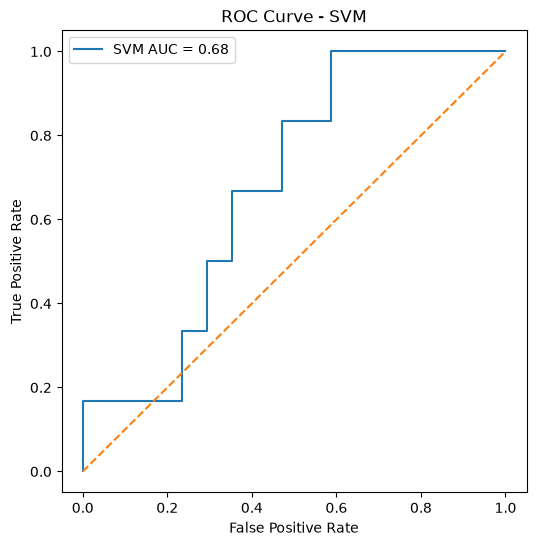

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability-like scores
y_scores = svm_model.decision_function(X_test_scaled)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

In [16]:
!pip install shap -q

import shap
import numpy as np

# Create explainer
explainer = shap.LinearExplainer(
    svm_model,
    X_train_scaled
)

# SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print(np.array(shap_values).shape)

c:\Users\LENOVO\anaconda3\envs\biomarker\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(23, 100)


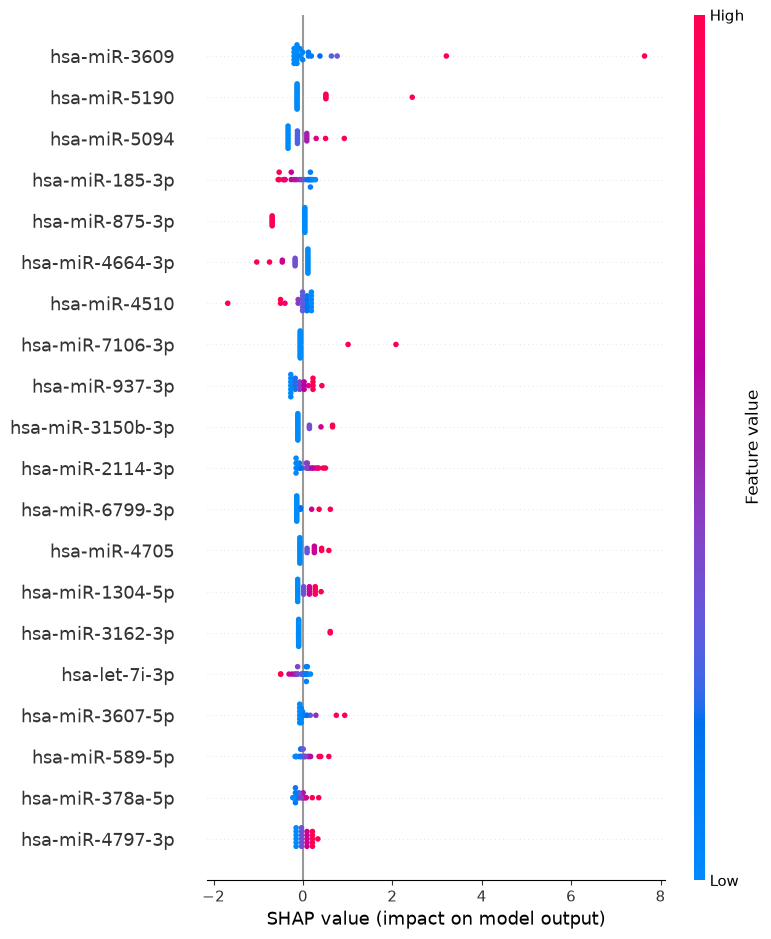

In [17]:
import matplotlib.pyplot as plt

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [18]:
# Mean absolute SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': shap_importance
})

# Sort
shap_df = shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Top biomarkers
display(shap_df.head(20))

,miRNA,SHAP_Importance
45,hsa-miR-3609,0.652839
65,hsa-miR-5190,0.298565
62,hsa-miR-5094,0.267356
11,hsa-miR-185-3p,0.246716
94,hsa-miR-875-3p,0.238501
55,hsa-miR-4664-3p,0.223065
53,hsa-miR-4510,0.214431
90,hsa-miR-7106-3p,0.189873
97,hsa-miR-937-3p,0.188568
29,hsa-miR-3150b-3p,0.178591


# Model building #2

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.6521739130434783

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       0.38      0.50      0.43         6

    accuracy                           0.65        23
   macro avg       0.59      0.60      0.59        23
weighted avg       0.69      0.65      0.67        23


Confusion Matrix:

[[12  5]
 [ 3  3]]


In [20]:
from sklearn.model_selection import cross_val_score

# Cross-validation
lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("CV Scores:")
print(lr_cv_scores)

print("\nMean CV Accuracy:")
print(lr_cv_scores.mean())

print("\nSTD:")
print(lr_cv_scores.std())

CV Scores:
[0.83333333 0.83333333 0.88888889 0.94117647 0.64705882]

Mean CV Accuracy:
0.8287581699346406

STD:
0.0993076979978225


Logistic Regression AUC: 0.7549019607843137


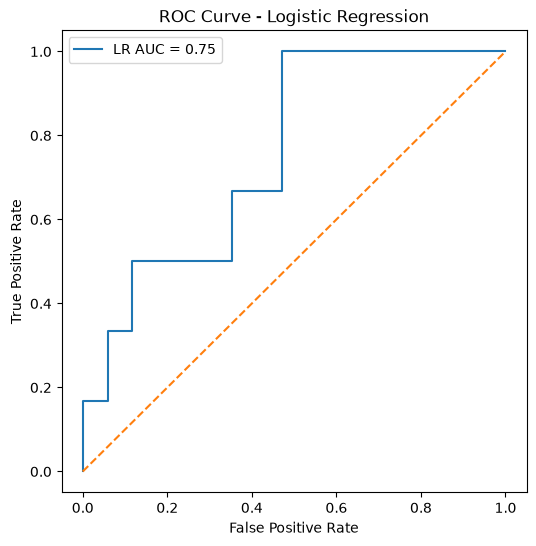

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability scores
y_scores_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_scores_lr)

# AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

print("Logistic Regression AUC:", roc_auc_lr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"LR AUC = {roc_auc_lr:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [22]:
import numpy as np
import pandas as pd

# Coefficient importance
lr_importance = np.abs(lr_model.coef_[0])

# Create dataframe
lr_biomarkers = pd.DataFrame({
    'miRNA': selected_features,
    'Coefficient_Importance': lr_importance
})

# Sort
lr_biomarkers = lr_biomarkers.sort_values(
    by='Coefficient_Importance',
    ascending=False
)

# Top biomarkers
display(lr_biomarkers.head(20))


,miRNA,Coefficient_Importance
45,hsa-miR-3609,0.788112
62,hsa-miR-5094,0.747151
53,hsa-miR-4510,0.741882
97,hsa-miR-937-3p,0.662995
90,hsa-miR-7106-3p,0.610248
31,hsa-miR-3162-3p,0.581156
65,hsa-miR-5190,0.575738
52,hsa-miR-4430,0.549588
55,hsa-miR-4664-3p,0.546137
48,hsa-miR-378g,0.514043


In [23]:
import shap
import numpy as np

# Explainer
lr_explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)

# SHAP values
lr_shap_values = lr_explainer.shap_values(X_test_scaled)

print(np.array(lr_shap_values).shape)

(23, 100)


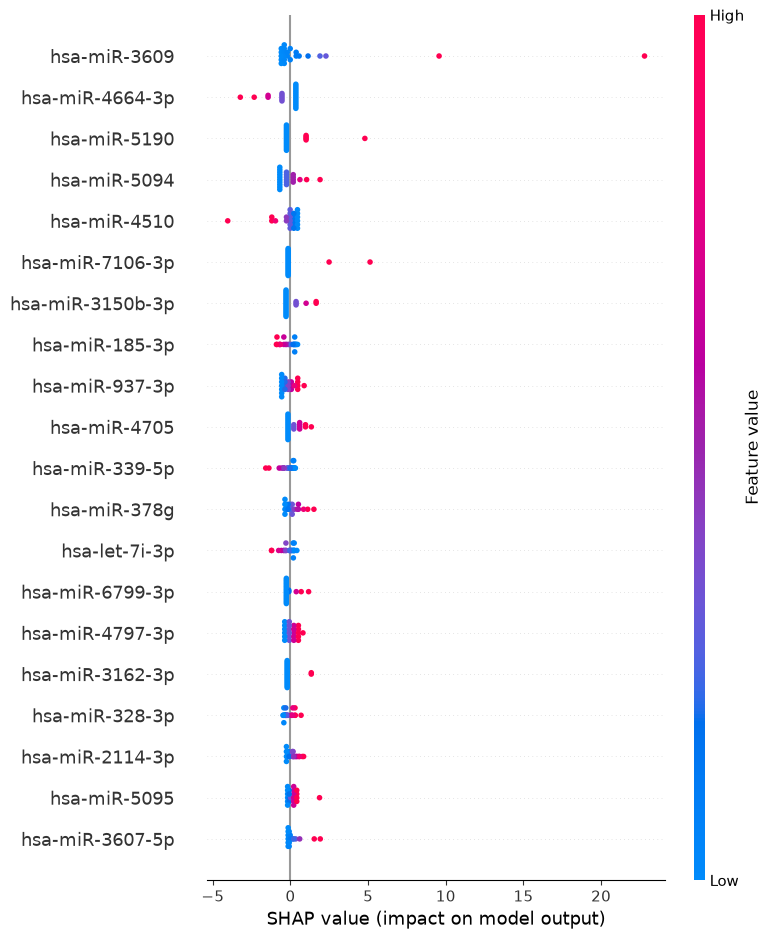

In [24]:
import matplotlib.pyplot as plt

# SHAP summary plot
shap.summary_plot(
    lr_shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [25]:
# Mean absolute SHAP importance
lr_shap_importance = np.abs(lr_shap_values).mean(axis=0)

# DataFrame
lr_shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': lr_shap_importance
})

# Sort
lr_shap_df = lr_shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Display top biomarkers
display(lr_shap_df.head(20))



,miRNA,SHAP_Importance
45,hsa-miR-3609,1.947361
55,hsa-miR-4664-3p,0.696758
65,hsa-miR-5190,0.584813
62,hsa-miR-5094,0.550625
53,hsa-miR-4510,0.514671
90,hsa-miR-7106-3p,0.467573
29,hsa-miR-3150b-3p,0.446057
11,hsa-miR-185-3p,0.403296
97,hsa-miR-937-3p,0.392316
56,hsa-miR-4705,0.364988


#COMPARISON OF MODELS

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract metrics for SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_precision = svm_report['macro avg']['precision']
svm_recall = svm_report['macro avg']['recall']
svm_f1 = svm_report['macro avg']['f1-score']
# roc_auc for SVM is roc_auc from cell vQ16YF6OQgZ5
svm_auc = roc_auc
# Mean CV Accuracy for SVM is cv_scores.mean() from cell 21DUFM5dQUib
svm_cv_mean_accuracy = cv_scores.mean()

# Extract metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
lr_precision = lr_report['macro avg']['precision']
lr_recall = lr_report['macro avg']['recall']
lr_f1 = lr_report['macro avg']['f1-score']
# roc_auc_lr for Logistic Regression is roc_auc_lr from cell CjqPIuIkR_lM
lr_auc = roc_auc_lr
# Mean CV Accuracy for Logistic Regression is lr_cv_scores.mean() from cell iIUREe42R2S6
lr_cv_mean_accuracy = lr_cv_scores.mean()

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy (Test Set)', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-score (Macro Avg)', 'AUC (Test Set)', '5-fold CV Mean Accuracy'],
    'SVM': [
        f'{svm_accuracy:.2f}',
        f'{svm_precision:.2f}',
        f'{svm_recall:.2f}',
        f'{svm_f1:.2f}',
        f'{svm_auc:.2f}',
        f'{svm_cv_mean_accuracy:.2f}'
    ],
    'Logistic Regression': [
        f'{lr_accuracy:.2f}',
        f'{lr_precision:.2f}',
        f'{lr_recall:.2f}',
        f'{lr_f1:.2f}',
        f'{lr_auc:.2f}',
        f'{lr_cv_mean_accuracy:.2f}'
    ]
})

display(comparison_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(10, 4)) # Adjust size as needed
ax.axis('off') # Hide axes

# Create the table
table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2) # Scale for better readability

ax.set_title('Model Performance Comparison', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('model_comparison_table.png', bbox_inches='tight', dpi=300)
plt.close()

print("Model comparison table saved as 'model_comparison_table.png'")

,Metric,SVM,Logistic Regression
0,Accuracy (Test Set),0.65,0.65
1,Precision (Macro Avg),0.55,0.59
2,Recall (Macro Avg),0.55,0.60
3,F1-score (Macro Avg),0.55,0.59
4,AUC (Test Set),0.68,0.75
5,5-fold CV Mean Accuracy,0.78,0.83


Model comparison table saved as 'model_comparison_table.png'


In [27]:
comparison_df1 = comparison_df.T
display(comparison_df1)


,0,1,2,3,4,5
Metric,Accuracy (Test Set),Precision (Macro Avg),Recall (Macro Avg),F1-score (Macro Avg),AUC (Test Set),5-fold CV Mean Accuracy
SVM,0.65,0.55,0.55,0.55,0.68,0.78
Logistic Regression,0.65,0.59,0.60,0.59,0.75,0.83


# comparision of biomarkers

In [28]:
# Top 20 from each method

svm_top = set(feature_importance_df.head(20)['miRNA'])

svm_shap_top = set(shap_df.head(20)['miRNA'])

lr_top = set(lr_biomarkers.head(20)['miRNA'])

lr_shap_top = set(lr_shap_df.head(20)['miRNA'])

print("Done")

Done


In [29]:
# Find consensus biomarkers

consensus = (
    svm_top &
    svm_shap_top &
    lr_top &
    lr_shap_top
)

print("Consensus Biomarkers:\n")
print(consensus)

print("\nNumber of consensus biomarkers:")
print(len(consensus))

Consensus Biomarkers:

{'hsa-miR-7106-3p', 'hsa-miR-4510', 'hsa-miR-5190', 'hsa-miR-5094', 'hsa-miR-3150b-3p', 'hsa-miR-185-3p', 'hsa-miR-937-3p', 'hsa-miR-3162-3p', 'hsa-miR-6799-3p', 'hsa-miR-3607-5p', 'hsa-miR-4664-3p', 'hsa-miR-3609'}

Number of consensus biomarkers:
12


In [30]:
# Convert to dataframe
consensus_df = pd.DataFrame({
    'Consensus_miRNA': list(consensus)
})

display(consensus_df)



,Consensus_miRNA
0,hsa-miR-7106-3p
1,hsa-miR-4510
2,hsa-miR-5190
3,hsa-miR-5094
4,hsa-miR-3150b-3p
5,hsa-miR-185-3p
6,hsa-miR-937-3p
7,hsa-miR-3162-3p
8,hsa-miR-6799-3p
9,hsa-miR-3607-5p


# evaluation with deSeq

In [33]:
res = pd.read_csv(r"F:\downloads microsodt\est_DESeq2_results.csv")

display(res.head(5))
display(res.shape)

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,hsa.miR.501.3p,609.605884,-1.514447,0.254244,-5.956666,2.574352e-09,0.000003
1,hsa.miR.934,3.779596,2.051007,0.373419,5.492513,3.962533e-08,0.000022
2,hsa.miR.3607.5p,2.559635,2.471624,0.471926,5.237313,1.629309e-07,0.000059
3,hsa.miR.1827,3.740322,-2.551829,0.504135,-5.061799,4.153182e-07,0.000076
4,hsa.miR.425.3p,79.396741,-0.752515,0.148374,-5.071746,3.941826e-07,0.000076


(2588, 7)

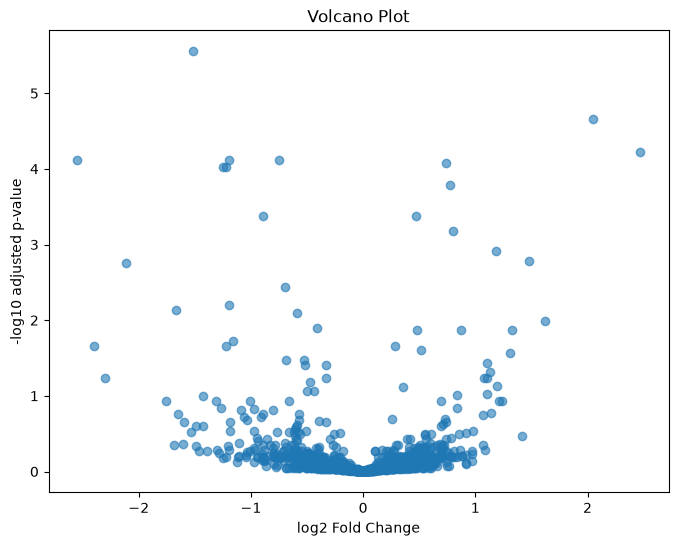

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

res = pd.read_csv(r"F:\downloads microsodt\est_DESeq2_results.csv")

plt.figure(figsize=(8,6))

plt.scatter(
    res["log2FoldChange"],
    -np.log10(res["padj"]),
    alpha=0.6
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot")

plt.show()

In [35]:
sig = res[
    (res["padj"] < 0.05) &
    (abs(res["log2FoldChange"]) > 1)
]

sig_mirnas = sig['Unnamed: 0'].tolist()

print(len(sig_mirnas))

20


In [36]:
# 1. DESeq2 significant miRNAs (already available from previous steps)
deseq2_mirnas = set([mirna.replace('.', '-') for mirna in sig_mirnas])

In [37]:
common_mirnas = consensus.intersection(deseq2_mirnas)

print("Common miRNAs between consensus and DESeq2:")
print(common_mirnas)
print(f"Number of common miRNAs: {len(common_mirnas)}")

Common miRNAs between consensus and DESeq2:
{'hsa-miR-4510', 'hsa-miR-3607-5p'}
Number of common miRNAs: 2


In [38]:
res_cleaned = res.copy()
res_cleaned['cleaned_mirna_name'] = res_cleaned['Unnamed: 0'].str.replace('.', '-', regex=False)

final_biomarkers_df = res_cleaned[res_cleaned['cleaned_mirna_name'].isin(common_mirnas)].set_index('Unnamed: 0')
print("DESeq2 values for Final Biomarkers:")
display(final_biomarkers_df)

DESeq2 values for Final Biomarkers:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cleaned_mirna_name
Unnamed: 0,,,,,,,
hsa.miR.3607.5p,2.559635,2.471624,0.471926,5.237313,1.629309e-07,0.000059,hsa-miR-3607-5p
hsa.miR.4510,1.041423,-1.666906,0.435419,-3.828278,1.290427e-04,0.007410,hsa-miR-4510


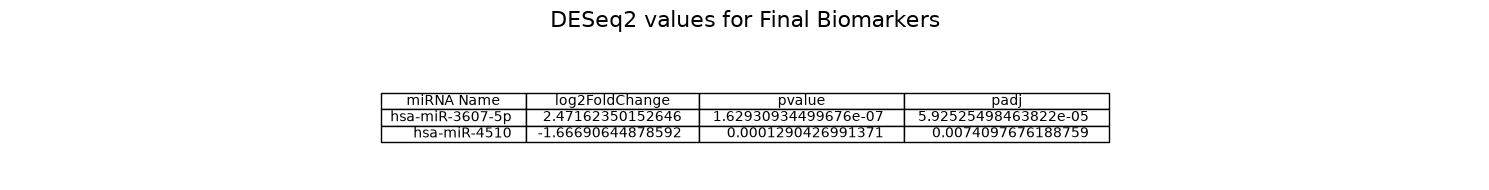

Saved as table_of_final_biomarkers_deseq2.png


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Use final_biomarkers_df directly
# Reset index to include 'Unnamed: 0' as a column in the table
df_temp = final_biomarkers_df.reset_index()

# Select only the relevant columns: miRNA name, log2FoldChange, pvalue, and padj
df_to_display = df_temp[['cleaned_mirna_name', 'log2FoldChange', 'pvalue', 'padj']]

# Rename 'cleaned_mirna_name' to 'miRNA Name' for better presentation
df_to_display = df_to_display.rename(columns={'cleaned_mirna_name': 'miRNA Name'})

# Create figure
# Adjust figsize dynamically based on the number of rows in the DataFrame and number of columns
fig, ax = plt.subplots(figsize=(15, len(df_to_display)*0.5 + 1))
ax.axis('off')

# Add a title for better presentation
ax.set_title('DESeq2 values for Final Biomarkers', loc='center', fontsize=16, pad=20)

# Create table
table = ax.table(
    cellText=df_to_display.values,
    colLabels=df_to_display.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Automatically adjust column widths for better presentation
table.auto_set_column_width(col=list(range(len(df_to_display.columns))))

# Ensure tight layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()


# Save as PNG
plt.savefig(
    "table_of_final_biomarkers_deseq2.png", # Changed filename
    bbox_inches='tight',
    dpi=300
)

plt.close()

print("Saved as table_of_final_biomarkers_deseq2.png")

Heat Map

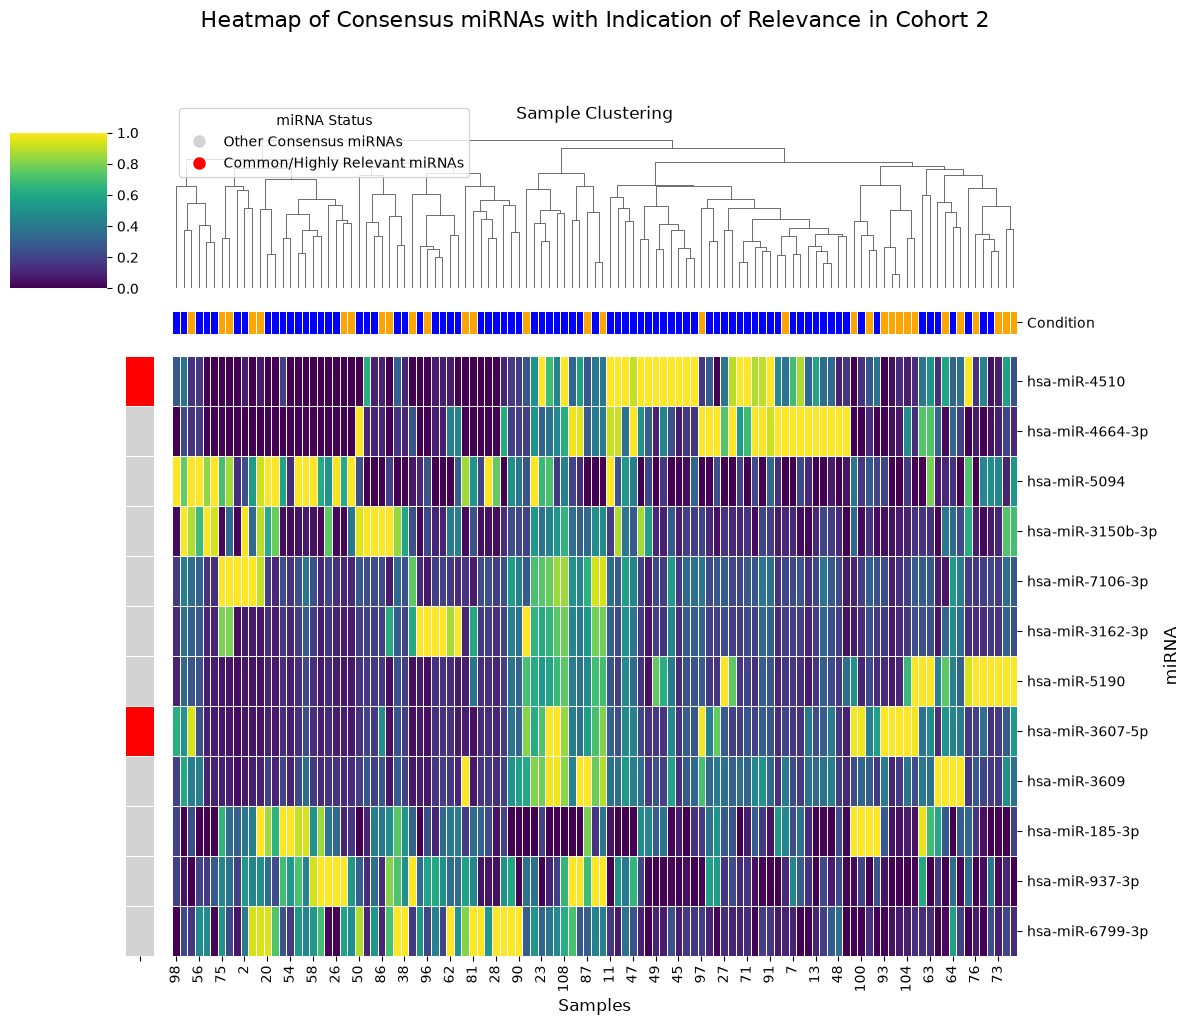

Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of consensus miRNAs from the 'consensus' set
consensus_mirnas_list = list(consensus)

# Filter the original feature DataFrame (X) to include only consensus miRNAs
# Ensure column names in X match the format in consensus_mirnas_list
# X.columns are already in the correct format (e.g., 'hsa-miR-4478')
heatmap_data = X[consensus_mirnas_list]

# Prepare column annotations for sample conditions (RIF vs. Control)
# Get the 'Condition' from the original final_ml_df for samples corresponding to X
sample_conditions = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']

# Create a color mapping for conditions
condition_colors_map = {'CONTROL': 'blue', 'IVF': 'orange'}
col_colors = sample_conditions.map(condition_colors_map)

# Create a color map for row annotations (since miRNAs will be rows after transposing)
# Common miRNAs (from DESeq2 integration) will be highlighted as most relevant
row_colors = pd.Series('lightgrey', index=heatmap_data.columns)

# 'common_mirnas' is already defined from previous steps as the intersection of consensus and DESeq2 significant miRNAs
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = 'red'

# Standardize the data (important for heatmaps, especially when comparing expression levels)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_heatmap_data = pd.DataFrame(scaler.fit_transform(heatmap_data), columns=heatmap_data.columns, index=heatmap_data.index)

# Generate the heatmap using seaborn.clustermap for hierarchical clustering
# This provides a comprehensive visualization suitable for research papers
g = sns.clustermap(
    scaled_heatmap_data.T, # Transpose to have miRNAs as rows and samples as columns
    cmap='viridis', # A perceptually uniform colormap
    standard_scale=1, # Standardize across features (miRNAs)
    figsize=(12, 10), # Adjust figure size for publication quality
    row_colors=row_colors, # Apply the highlighting colors to rows (miRNAs)
    col_colors=col_colors, # Apply colors to columns (samples) based on condition
    dendrogram_ratio=(0.1, 0.2), # Adjust dendrogram sizes
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the color bar (left, bottom, width, height)
    linewidths=0.5, # Add lines between cells
    linecolor='white'
)

# Customize the plot for research paper quality
g.ax_row_dendrogram.set_visible(False) # Hide row dendrogram if not critical for interpretation
g.ax_col_dendrogram.set_title('Sample Clustering', fontsize=12, pad=10) # Title for sample dendrogram
g.ax_heatmap.set_ylabel('miRNA', fontsize=12)
g.ax_heatmap.set_xlabel('Samples', fontsize=12)

# Rotate miRNA labels for readability
g.ax_heatmap.tick_params(axis='y', rotation=0)

# Add a title to the entire figure
g.fig.suptitle('Heatmap of Consensus miRNAs with Indication of Relevance in Cohort 2', y=1.02, fontsize=16)

# Create a legend for the row colors (miRNA relevance)
highlight_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='lightgrey', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Common/Highly Relevant miRNAs', markerfacecolor='red', markersize=10)
]
# Create a legend for the column colors (sample conditions)
condition_patches = [
    plt.Line2D([0], [0], marker='s', color='w', label='CONTROL Samples', markerfacecolor=condition_colors_map['CONTROL'], markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='IVF Samples', markerfacecolor=condition_colors_map['IVF'], markersize=10)
]

# Position the legends
g.ax_col_dendrogram.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='miRNA Status')
g.ax_row_dendrogram.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='Sample Condition') # Adjusted to ax_row_dendrogram for sample legend

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap

# Save the plot as a high-resolution PNG image
plt.savefig('consensus_mirna_heatmap_relevant_with_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'")

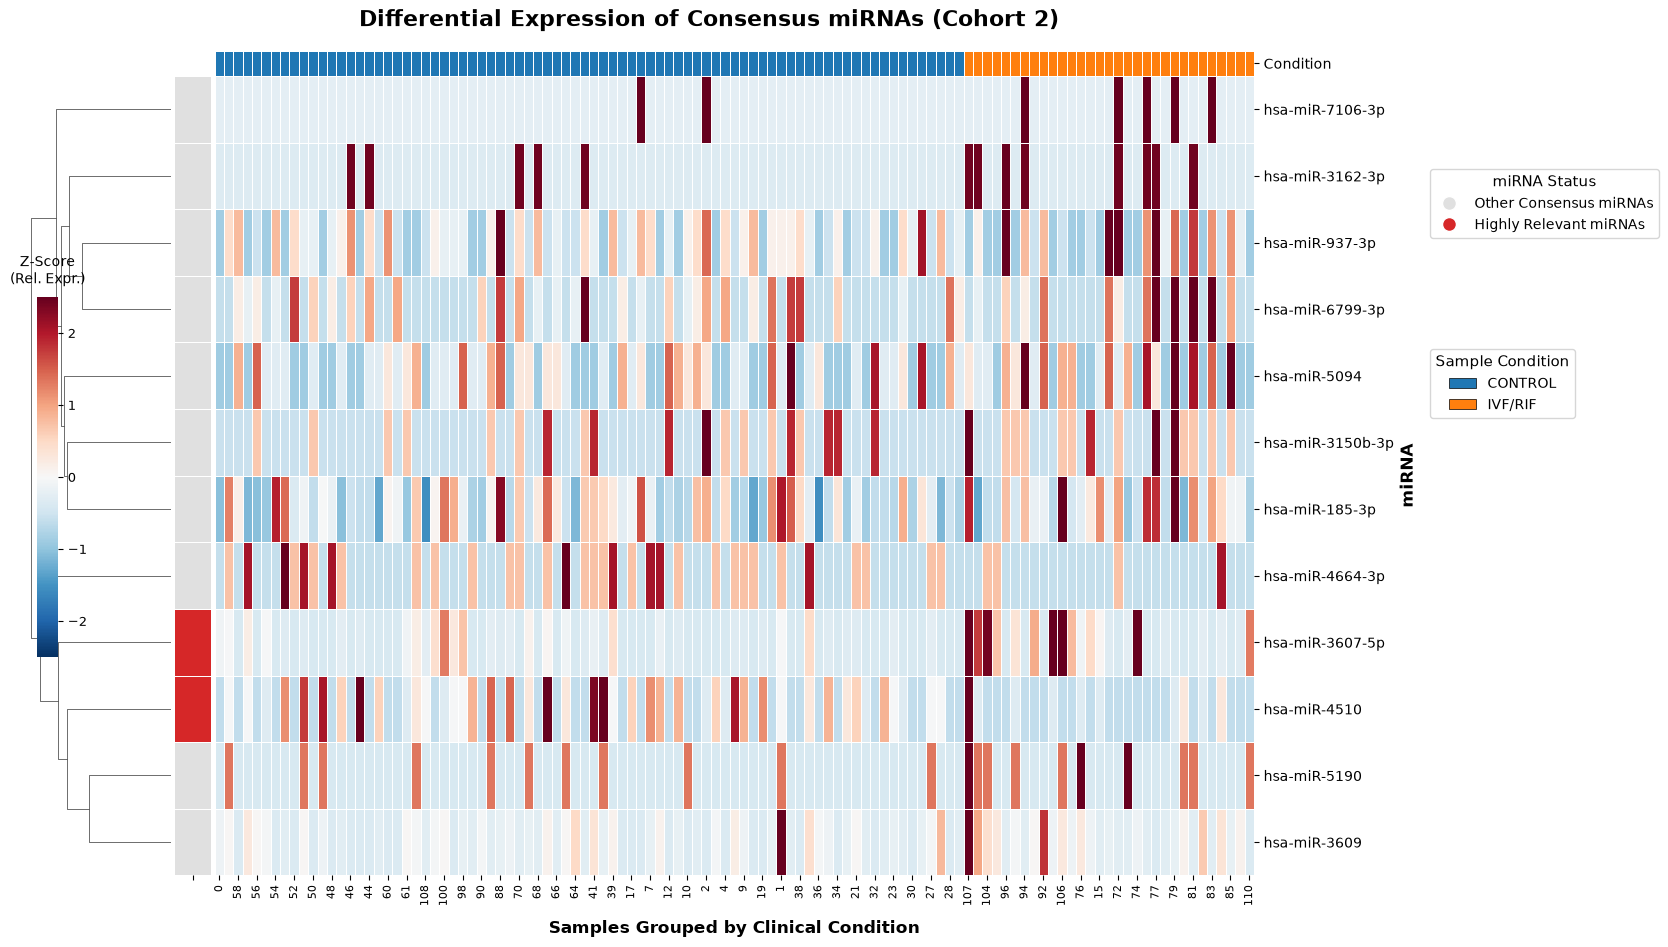

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Prepare and Sort the Data (Same as before)
consensus_mirnas_list = list(consensus)
heatmap_data = X[consensus_mirnas_list].copy()

heatmap_data['Condition'] = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']
heatmap_data = heatmap_data.sort_values(by='Condition')

sample_conditions = heatmap_data['Condition']
heatmap_data = heatmap_data.drop(columns=['Condition'])

# Color mapping for samples
condition_colors_map = {'CONTROL': '#1f77b4', 'IVF': '#ff7f0e'} # Using standard muted hex colors for pub
col_colors = sample_conditions.map(condition_colors_map)

# Color mapping for key miRNAs
row_colors = pd.Series('#e0e0e0', index=heatmap_data.columns) # Light grey hex
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = '#d62728' # Deep red hex

# 2. Generate the Clustermap with Fixed Grid Spacing
g = sns.clustermap(
    heatmap_data.T,
    cmap='RdBu_r',
    z_score=0,
    center=0,
    col_cluster=False,
    row_cluster=True,
    figsize=(14, 9),              # CHANGED: Wider, shorter aspect ratio fits this data better
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.12, 0.01),# CHANGED: Shrinks the empty top space to 1%, fixing the massive gap
    colors_ratio=0.03,            # CHANGED: Makes the annotation color bars thinner and more elegant
    cbar_pos=(0.02, 0.3, 0.015, 0.4), # CHANGED: Places the colorbar cleanly on the middle-left
    linewidths=0.5,
    linecolor='white',
    vmin=-2.5, vmax=2.5
)

# 3. Clean up the Aesthetics for Publication
# Hide the practically empty column dendrogram axis completely
g.ax_col_dendrogram.set_visible(False)

# Format the Colorbar (Z-score)
g.ax_cbar.set_title('Z-Score\n(Rel. Expr.)', fontsize=10, pad=10)
g.ax_cbar.tick_params(labelsize=9)

# Format the Main Axes
g.ax_heatmap.set_ylabel('miRNA', fontsize=12, fontweight='bold')
g.ax_heatmap.set_xlabel('Samples Grouped by Clinical Condition', fontsize=12, fontweight='bold', labelpad=10)
g.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=10)
g.ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8) # Rotate sample IDs to prevent overlapping

# Main Title
g.fig.suptitle('Differential Expression of Consensus miRNAs (Cohort 2)', y=1.02, fontsize=16, fontweight='bold')

# 4. Build Professional Legends
highlight_patches = [
    Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='#e0e0e0', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Highly Relevant miRNAs', markerfacecolor='#d62728', markersize=10)
]
condition_patches = [
    Patch(facecolor='#1f77b4', label='CONTROL', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#ff7f0e', label='IVF/RIF', edgecolor='black', linewidth=0.5)
]

# Place legends cleanly outside the plot area on the right side
g.fig.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(1.01, 0.85), fontsize=10, title='miRNA Status', title_fontsize=11)
g.fig.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(1.01, 0.65), fontsize=10, title='Sample Condition', title_fontsize=11)

# Ensure nothing gets cut off when saving
#plt.tight_layout(rect=[0.05, 0, 0.95, 0.98]) # [left, bottom, right, top]

# Save as high-resolution Tiff/PNG (TIFF is often preferred for journals, but PNG is fine for drafts)
plt.savefig('est_consensus1_mirna_heatmap_publication.png', dpi=300, bbox_inches='tight')
plt.show()

volcano map

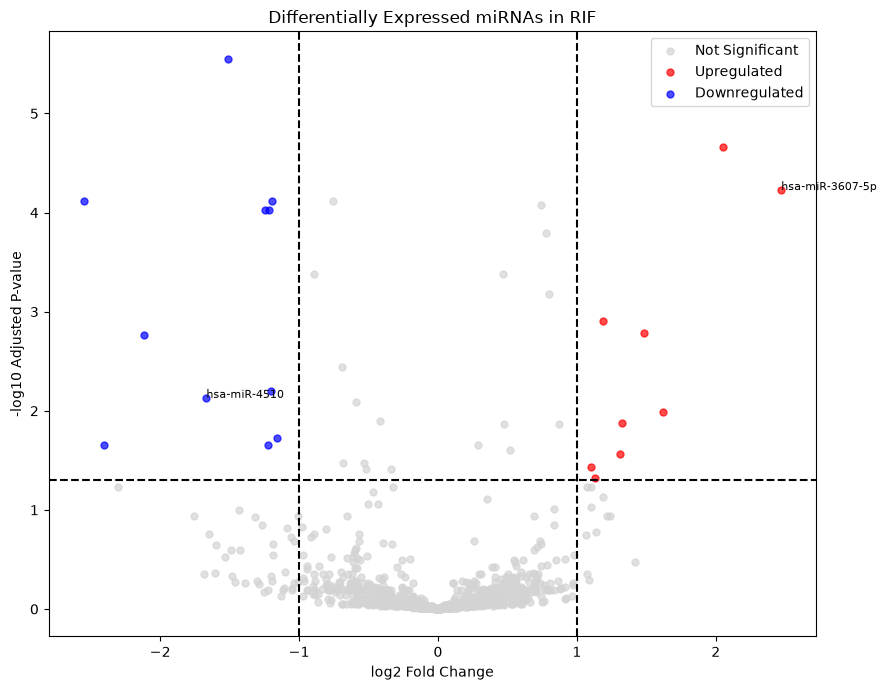

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.read_csv(r"F:\downloads microsodt\est_DESeq2_results.csv")

# Rename 'Unnamed: 0' column to 'miRNA Name' for clarity and consistency
res = res.rename(columns={'Unnamed: 0': 'miRNA Name'})
# Clean miRNA names by replacing '.' with '-' to match the 'important' list format
res['miRNA Name'] = res['miRNA Name'].str.replace('.', '-', regex=False)

res["group"] = "Not Significant"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] > 1),
    "group"
] = "Upregulated"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] < -1),
    "group"
] = "Downregulated"

colors = {
    "Not Significant":"lightgray",
    "Upregulated":"red",
    "Downregulated":"blue"
}

plt.figure(figsize=(9,7))

for group, color in colors.items():
    subset = res[res["group"] == group]

    plt.scatter(
        subset["log2FoldChange"],
        -np.log10(subset["padj"]),
        c=color,
        s=25,
        alpha=0.7,
        label=group
    )

plt.axhline(-np.log10(0.05),
            linestyle='--',
            color='black')

plt.axvline(1,
            linestyle='--',
            color='black')

plt.axvline(-1,
            linestyle='--',
            color='black')

important = [
    "hsa-miR-4510",
    "hsa-miR-3607-5p"
]

for _, row in res.iterrows():
    # Check if the miRNA name (now cleaned) is in the important list
    if row["miRNA Name"] in important:

        plt.text(
            row["log2FoldChange"],
            -np.log10(row["padj"]),
            row["miRNA Name"],
            fontsize=8
        )

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Differentially Expressed miRNAs in RIF")
plt.legend()
plt.tight_layout()
plt.show()

## p log

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure final_biomarkers_df is available and properly indexed
# If it's already indexed by 'Unnamed: 0' (miRNA names), reset for easier access
if 'Unnamed: 0' not in final_biomarkers_df.columns:
    final_biomarkers_df_reset = final_biomarkers_df.reset_index()
else:
    final_biomarkers_df_reset = final_biomarkers_df.copy()

# Filter for the specific miRNAs requested
target_mirnas = ['hsa-miR-4510', 'hsa-miR-3607-5p']
filtered_df = final_biomarkers_df_reset[final_biomarkers_df_reset['cleaned_mirna_name'].isin(target_mirnas)].copy()

# Calculate Fold Change (2^log2FC)
filtered_df['Fold Change'] = 2**filtered_df['log2FoldChange']

# Determine Regulation
filtered_df['Regulation'] = filtered_df['log2FoldChange'].apply(lambda x: 'Up-regulated' if x > 0 else 'Down-regulated')

# Select and rename columns for the final table
final_table_df = filtered_df[[
    'cleaned_mirna_name',
    'log2FoldChange',
    'Fold Change',
    'pvalue',
    'padj',
    'Regulation'
]].rename(columns={
    'cleaned_mirna_name': 'miRNA',
    'log2FoldChange': 'log2FC',
    'pvalue': 'p-value',
    'padj': 'FDR (padj)'
})

# Format numeric columns for better readability
final_table_df['log2FC'] = final_table_df['log2FC'].round(3)
final_table_df['Fold Change'] = final_table_df['Fold Change'].round(2)
final_table_df['p-value'] = final_table_df['p-value'].apply(lambda x: f'{x:.2e}')
final_table_df['FDR (padj)'] = final_table_df['FDR (padj)'].apply(lambda x: f'{x:.2e}')

display(final_table_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1)) # Adjust size dynamically
ax.axis('off')

# Create the table
table = ax.table(
    cellText=final_table_df.values,
    colLabels=final_table_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

ax.set_title('Significance of Key miRNAs in Disease', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('key_mirna_significance_table.png', bbox_inches='tight', dpi=300)
plt.close()

print("Table of key miRNA significance saved as 'key_mirna_significance_table.png'")

,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-3607-5p,2.472,5.55,1.63e-07,5.93e-05,Up-regulated
1,hsa-miR-4510,-1.667,0.31,1.29e-04,7.41e-03,Down-regulated


Table of key miRNA significance saved as 'key_mirna_significance_table.png'
